# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
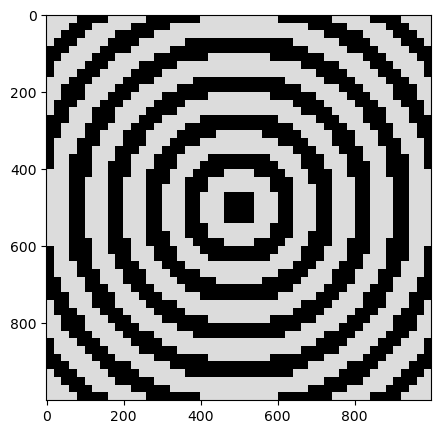


# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
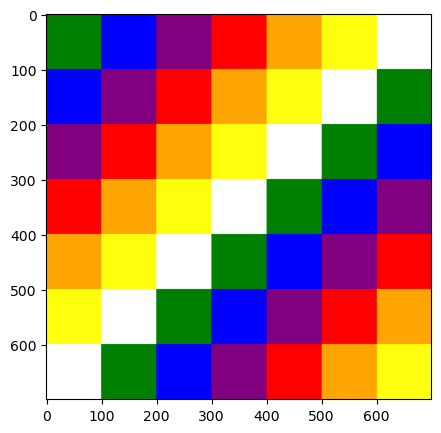

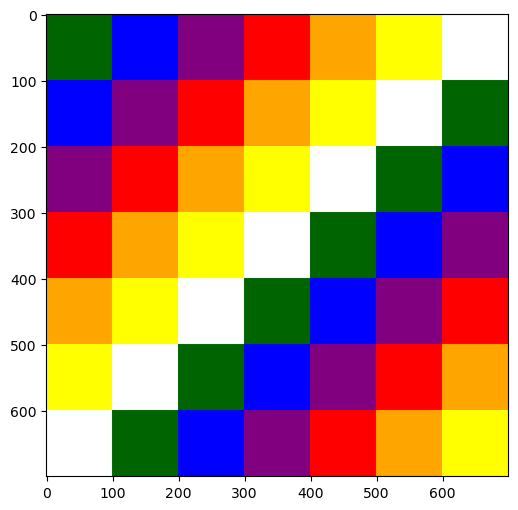

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=[6,6]

tam = 100

imagen = np.ones((tam*7, tam*7, 3), dtype=np.uint8) * 255

verde = [0, 100, 0]
azul = [0, 0, 255]
morado = [128, 0, 128]
naranja = [255, 165, 0]
amarillo = [255, 255, 0]
blanco = [255, 255, 255]
rojo = [255, 0, 0]



imagen[0:100, 0:100] = verde
imagen[0:100, 100:200] = azul
imagen[0:100, 200:300] = morado
imagen[0:100, 300:400] = rojo
imagen[0:100, 400:500] = naranja
imagen[0:100, 500:600] = amarillo
imagen[0:100, 600:700] = blanco


imagen[100:200, 0:100] = azul
imagen[100:200, 100:200] = morado
imagen[100:200, 200:300] = rojo
imagen[100:200, 300:400] = naranja
imagen[100:200, 400:500] = amarillo
imagen[100:200, 500:600] = blanco
imagen[100:200, 600:700] = verde


imagen[200:300, 0:100] = morado
imagen[200:300, 100:200] = rojo
imagen[200:300, 200:300] = naranja
imagen[200:300, 300:400] = amarillo
imagen[200:300, 400:500] = blanco
imagen[200:300, 500:600] = verde
imagen[200:300, 600:700] = azul


imagen[300:400, 0:100] = rojo
imagen[300:400, 100:200] = naranja
imagen[300:400, 200:300] = amarillo
imagen[300:400, 300:400] = blanco
imagen[300:400, 400:500] = verde
imagen[300:400, 500:600] = azul
imagen[300:400, 600:700] = morado


imagen[400:500, 0:100] = naranja
imagen[400:500, 100:200] = amarillo
imagen[400:500, 200:300] = blanco
imagen[400:500, 300:400] = verde
imagen[400:500, 400:500] = azul
imagen[400:500, 500:600] = morado
imagen[400:500, 600:700] = rojo


imagen[400:500, 0:100] = naranja
imagen[400:500, 100:200] = amarillo
imagen[400:500, 200:300] = blanco
imagen[400:500, 300:400] = verde
imagen[400:500, 400:500] = azul
imagen[400:500, 500:600] = morado
imagen[400:500, 600:700] = rojo


imagen[500:600, 0:100] = amarillo
imagen[500:600, 100:200] = blanco
imagen[500:600, 200:300] = verde
imagen[500:600, 300:400] = azul
imagen[500:600, 400:500] = morado
imagen[500:600, 500:600] = rojo
imagen[500:600, 600:700] = naranja


imagen[600:700, 0:100] = blanco
imagen[600:700, 100:200] = verde
imagen[600:700, 200:300] = azul
imagen[600:700, 300:400] = morado
imagen[600:700, 400:500] = rojo
imagen[600:700, 500:600] = naranja
imagen[600:700, 600:700] = amarillo


plt.imshow(imagen)
plt.show()


# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

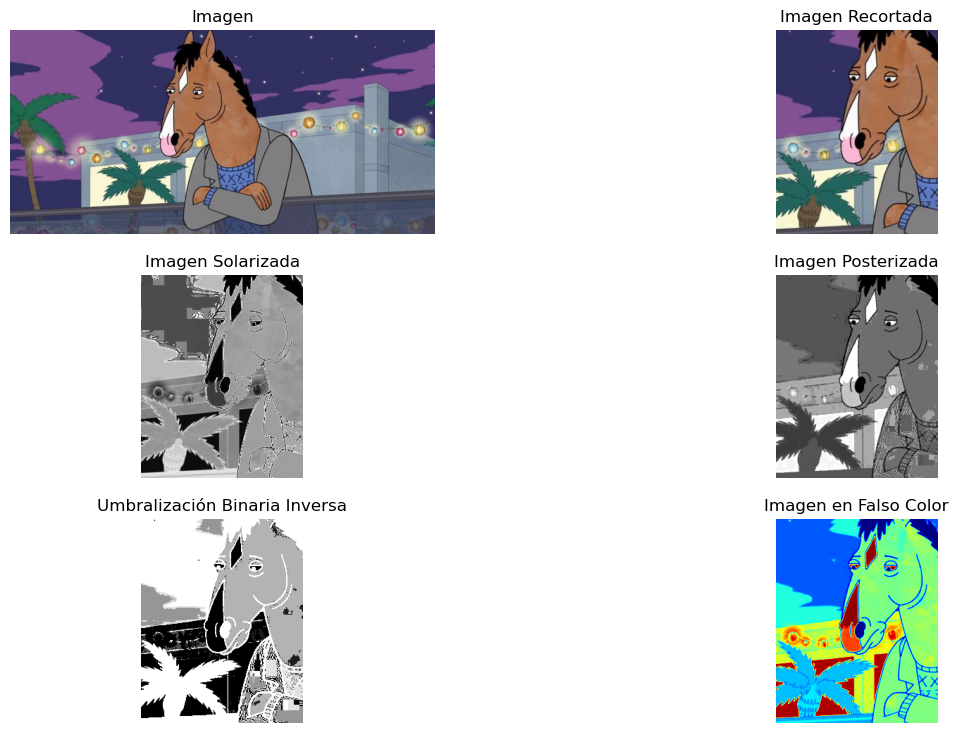

In [142]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt




img = cv2.imread('imagen1.jpg')

def recortar_imagen_random(img, x, y, height, width):
    x_random = np.random.randint(0, img.shape[1] - width)
    y_random = np.random.randint(0, img.shape[0] - height)
    return img[y_random:y_random + height, x_random:x_random + width]
img_recortada = recortar_imagen_random(img, 0, 0, 290, 230)
#cv2.imwrite('lena_recortada.png', img_recortada) 


def solarizar(img_recortada, umbral):
    # APLICAMOS SOLARIZACION A LA IMAGEN
    imagen_sol = np.where(img_recortada < umbral, img_recortada, 255 - img_recortada)
    return imagen_sol

umbral = 50  # Definir el umbral para la solarización
img_fin_sol=solarizar(img_recortada, umbral)  # Aplicar la función de solarización


def posterizar(img_recortada, niveles):
    # APLICAMOS POSTERIZACION A LA IMAGEN
    factor_escala = 256 // niveles
    imagen_post = np.round(img_recortada / factor_escala) * factor_escala
    return imagen_post.astype(np.uint8) # Convertir a uint8 para mantener el formato de imagen


def falso_color(img_recortada):
    escal_img=cv2.normalize(img_recortada,None,0,255,cv2.NORM_MINMAX)
    falso_img=cv2.applyColorMap(escal_img,cv2.COLORMAP_JET)
    return falso_img

img_fin_fal=falso_color(img_recortada)  

nvles = 3  # Definir el número de niveles para la posterización
img_fin_pos=posterizar(img_recortada, nvles)  # Aplicar la función de posterización

# umbralización binaria
_, umbral_binario = cv2.threshold(img_recortada, 127, 255, cv2.THRESH_BINARY)

# umbralización binaria inversa
_, umbral_binario_in = cv2.threshold(img_recortada, 127, 255, cv2.THRESH_BINARY_INV)




plt.figure(figsize=(15, 9))
plt.subplot(3, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen')
plt.axis('off')


plt.subplot(3, 2, 2)
plt.imshow(cv2.cvtColor(img_recortada, cv2.COLOR_BGR2RGB))  
plt.title('Imagen Recortada')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(cv2.cvtColor(img_fin_sol, cv2.COLOR_BGR2GRAY), cmap='gray')
plt.title('Imagen Solarizada')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(cv2.cvtColor(img_fin_pos, cv2.COLOR_BGR2GRAY), cmap='gray')
plt.title('Imagen Posterizada')
plt.axis('off')


plt.subplot(3, 2, 5)
plt.imshow(cv2.cvtColor(umbral_binario_in, cv2.COLOR_BGR2GRAY), cmap='gray')
plt.title('Umbralización Binaria Inversa')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(cv2.cvtColor(img_fin_fal, cv2.COLOR_BGR2RGB))
plt.title('Imagen en Falso Color')
plt.axis('off')



plt.show()
# Guardado de todas las imágenes
plt.imsave('Original.png', img)

plt.imsave('IMG_recortada.png', img_recortada)
plt.imsave('IMG_solarizada.png', img_fin_sol)
plt.imsave('IMG_posterizada.png', img_fin_pos)
plt.imsave('IMG_umbral_binario_in.png', umbral_binario_in)
plt.imsave('IMG_falso_color.png', img_fin_fal)

# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

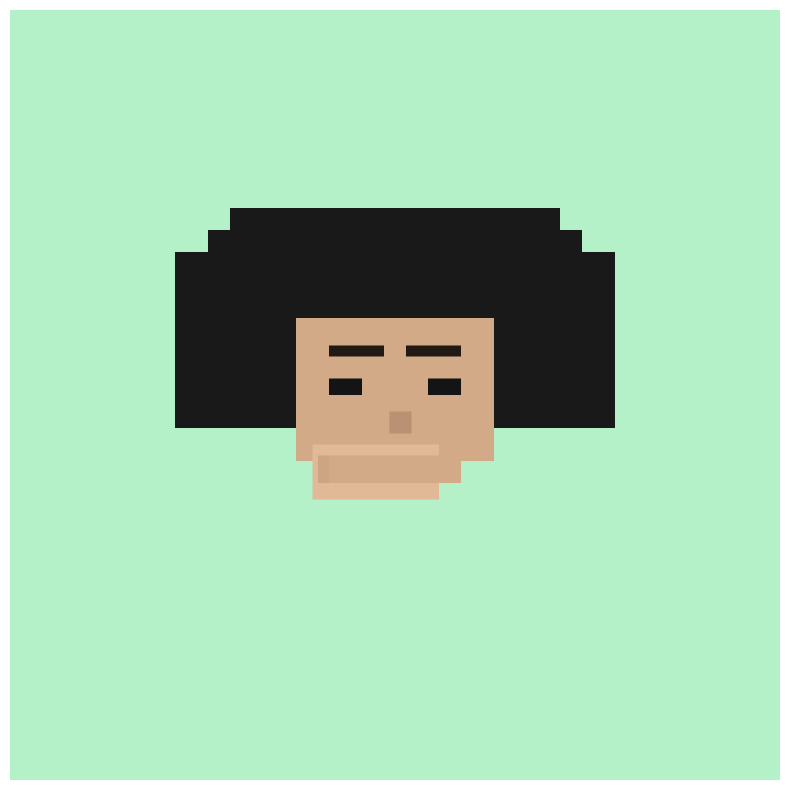

In [138]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [8, 8]

tam = 100
imagen = np.ones((tam*7, tam*7, 3), dtype=np.uint8) * 255


verde_pastel = [180, 240, 200]
imagen[:, :] = verde_pastel

negro = [25, 25, 25]          
piel = [210, 170, 135]        
ceja = [35, 25, 20]
ojo = [20, 20, 20]
mano = [225, 185, 150]


imagen[220:380, 150:250] = negro
imagen[220:380, 450:550] = negro
imagen[200:380, 180:520] = negro
imagen[180:380, 200:500] = negro   


imagen[280:410, 260:440] = piel


imagen[305:315, 290:340] = ceja
imagen[305:315, 360:410] = ceja


imagen[335:350, 290:320] = ojo
imagen[335:350, 380:410] = ojo


imagen[365:385, 345:365] = [185, 145, 115]


imagen[395:445, 275:390] = mano
imagen[405:430, 280:340] = [205, 165, 130]   


imagen[405:430, 290:410] = piel

plt.imshow(imagen)
plt.axis('off')
plt.tight_layout()
plt.show()

plt.imsave('Imagen_generada.png', imagen)